In [1]:
import spatialdata as sd
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from spatialdata import get_extent
from spatialdata import bounding_box_query
from spatialdata import match_element_to_table
import spatialdata_plot
import numpy as np
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from datatree import DataTree
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine
from sklearn.neighbors import KernelDensity
from easydecon.easydecon import *
from easydecon.config import *
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent
#import seaborn as sns
#import colorcet as cc
from matplotlib.colors import ListedColormap
from scipy.stats import zscore

pd.set_option('display.max_rows', 500)

from napari_spatialdata import Interactive
from spatialdata import polygon_query

/Users/sium/miniconda/envs/easydecon_test2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%reload_ext autoreload
%autoreload 2
from easydecon.easydecon import *
from easydecon.easydecon import *
test_function()

Easydecon loaded!
Test function executed!


In [ ]:
bin_size=8
sample_id="sampleP2"

# you want to replace the binned_outputs with the path to the binned outputs of the visium HD data and fullres_image_file with the path to the full resolution SCANNER image
sdata=spatialdata_io.visium_hd("../../sampleP2/binned_outputs/",
                               bin_size=bin_size,dataset_id=sample_id,load_all_images=True)
sdata

In [20]:
import scanpy as sc
sample_id="A1-C2215F1_hirs_ganglionic_bin2cell"
adata=sc.read_h5ad(f"/Users/sium/projects/colon/hirs/{sample_id}.h5ad")
img_key="0.5_mpp"

In [21]:
# Multi-ROI drawing aligned to histology (pixel coords), zoom control.
# Controls: drag to draw • Z=undo • Enter/Q=finish

import matplotlib
matplotlib.use("QtAgg")  # or "TkAgg"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path
from matplotlib.patches import Polygon as MplPolygon

# --- Settings
img_key = "0.5_mpp"
downsample_n = 80_000      # draw faster; full data used for labeling
pad_frac    = 0.15         # increase to "zoom out" (e.g., 0.35 for a larger view)
figsize     = (12, 12)     # larger canvas

# --- Data
xy = np.asarray(adata.obsm["spatial"])  # (n,2) in spot space

lib = next(iter(adata.uns["spatial"]))
sp  = adata.uns["spatial"][lib]
img = sp["images"][img_key]
h, w = img.shape[:2]

# scalefactor: pixels = spot * sf  (match by key; fallbacks if custom)
sf = next((v for k, v in sp.get("scalefactors", {}).items()
           if img_key in k and k.endswith("_scalef")), None)
if sf is None:
    sf = sp["scalefactors"].get("tissue_hires_scalef") \
         or sp["scalefactors"].get("tissue_lowres_scalef") \
         or 1.0

# Convert spots -> image pixel coords
xy_px = xy * sf

# Downsample only for display
n = xy_px.shape[0]
if n > downsample_n:
    rng = np.random.default_rng(0)
    disp_idx = rng.choice(n, downsample_n, replace=False)
    xy_disp = xy_px[disp_idx]
else:
    xy_disp = xy_px

# --- Plot in pixel coords (so image & points always align)
fig, ax = plt.subplots(figsize=figsize)
#ax.imshow(img, origin="upper", zorder=0)  # axes now ~ [0,w] x [h,0]
ax.plot(xy_disp[:, 0], xy_disp[:, 1], ',', alpha=0.35, zorder=1, rasterized=True)
ax.set_aspect("equal")
ax.set_title("Lasso ROIs: drag to draw. Z=undo, Enter/Q=finish.")

# Auto-zoom to tissue bbox with adjustable padding
minx, miny = xy_px.min(axis=0)
maxx, maxy = xy_px.max(axis=0)
pad = pad_frac * max(maxx - minx, maxy - miny)
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(maxy + pad, miny - pad)  # y inverted to match origin="upper"

# --- Interactive multi-ROI (store polygons in pixel coords)
polys_px, patches = [], []

def onselect(verts):
    v = np.asarray(verts)
    polys_px.append(v)
    p = MplPolygon(v, closed=True, alpha=0.25, zorder=2)
    patches.append(p)
    ax.add_patch(p)
    fig.canvas.draw_idle()

def on_key(event):
    if event.key in ("z", "backspace"):
        if patches:
            patches[-1].remove()
            patches.pop(); polys_px.pop()
            fig.canvas.draw_idle()
    elif event.key in ("enter", "q"):
        plt.close(fig)

selector = LassoSelector(ax, onselect, useblit=True)
cid = fig.canvas.mpl_connect('key_press_event', on_key)
plt.show(block=True)
fig.canvas.mpl_disconnect(cid)

# --- Label all spots (test in pixel coords for perfect alignment)
labels = np.array([None] * n, dtype=object)
for k, verts in enumerate(polys_px, start=1):
    path = Path(verts)
    inside = path.contains_points(xy_px)   # include boundary: radius=-1e-9
    labels[inside] = f"ROI_{k}"

adata.obs["region"] = pd.Categorical(labels)
adata.obs[['region']].to_csv(f'/Users/sium/projects/colon/hirs/{sample_id}_neural_roi.csv')

In [17]:
adata.obs["region"].value_counts()

region
ROI_1    16475
ROI_2    14187
Name: count, dtype: int64

In [20]:
adata

AnnData object with n_obs × n_vars = 93802 × 17740
    obs: 'bin_count', 'array_row', 'array_col', 'region'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped'

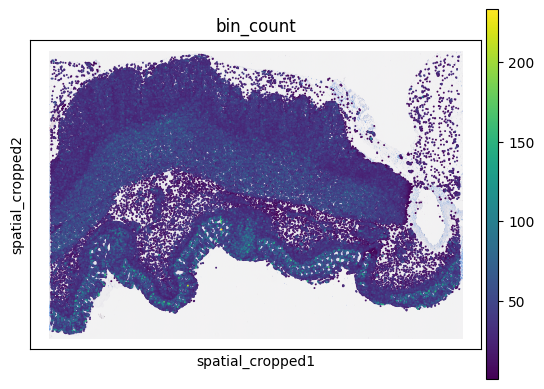

In [4]:
sc.pl.spatial(
        adata,
        color=[f"bin_count"],
        img_key="0.5_mpp",
        basis="spatial_cropped",




        size=3,
        na_in_legend=False,
        legend_loc=None
    )

In [14]:
Interactive(adata)

AttributeError: 'AnnData' object has no attribute 'coordinate_systems'

In [ ]:
sdata

In [ ]:
sdata["Shapes_external"].geometry.iloc[0]

In [ ]:
napari_region_assignment(sdata,key="Shapes_external",column="napari2",target_coordinate_system="downscaled_hires")

In [ ]:
sdata.tables[f"square_00{bin_size}um"].obs["napari"]